<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Proyecto Final

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00402237


## Modelado - Experimentos de Machine Learning Tradicional

Este notebook contiene los experimentos utilizando modelos clásicos (Random Forest, SVM, XGBoost) para predecir **simultáneamente** la calidad y el tamaño de las frutas/verduras usando un enfoque `MultiOutputClassifier`.

Siguiendo las mejores prácticas, las funciones de evaluación pesadas se han abstraído en `src/evaluation/evaluate.py`.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
from tqdm import tqdm


# Añadir la carpeta raíz al path para poder importar desde la carpeta src
sys.path.append(os.path.abspath('..'))

from src.evaluation.evaluate import evaluate_multioutput_model
from src.utils.helpers import extract_features_for_ml

### 1. Carga de Datos y Preprocesamiento

Para el Machine Learning tradicional, asumimos que las características (features) ya han sido extraídas en la fase de preparación de datos (ej. histogramas de color, descriptores de textura HOG, contornos). 

Aquí utilizaremos datos simulados representativos para mantener la estructura funcional. *Debes reemplazar esto con la carga de tus datos reales cuando estén listos.*

In [2]:
# --- Carga del metadata ---
metadata = pd.read_csv('../data/processed/metadata.csv')

# Codificar size_category a número (small=0, medium=1, large=2)
size_map = {'small': 0, 'medium': 1, 'large': 2}
metadata['size_label'] = metadata['size_category'].map(size_map)

# Usar solo imágenes NO aumentadas para evitar data leakage en la evaluación
# Las aumentadas se usan solo en entrenamiento, no en test
metadata_original = metadata[metadata['augmented'] == 0].copy()
metadata_augmented = metadata[metadata['augmented'] == 1].copy()

print(f"Imágenes originales: {len(metadata_original)}")
print(f"Imágenes aumentadas: {len(metadata_augmented)}")
print(f"Distribución calidad:\n{metadata_original['quality'].value_counts()}")
print(f"Distribución tamaño:\n{metadata_original['size_category'].value_counts()}")

# --- Extracción de features ---
BASE_PATH = '../data/processed/'

def extract_features_from_df(df):
    features = []
    failed = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extrayendo features"):
        img_path = BASE_PATH + row['file']
        try:
            feat = extract_features_for_ml(img_path)
            features.append(feat.flatten())
        except Exception as e:
            failed.append(row['file'])
    if failed:
        print(f"⚠️ {len(failed)} imágenes fallaron al cargarse.")
    return np.array(features)

# Extraer features de originales y aumentadas por separado
X_orig = extract_features_from_df(metadata_original)
y_quality_orig = metadata_original['label'].values
y_size_orig    = metadata_original['size_label'].values

X_aug  = extract_features_from_df(metadata_augmented)
y_quality_aug = metadata_augmented['label'].values
y_size_aug    = metadata_augmented['size_label'].values

print(f"\nShape features originales: {X_orig.shape}")  # (n_samples, 513)

Imágenes originales: 28395
Imágenes aumentadas: 113580
Distribución calidad:
quality
Good       14599
Bad         9142
Regular     4654
Name: count, dtype: int64
Distribución tamaño:
size_category
large     15305
medium    10540
small      2550
Name: count, dtype: int64


Extrayendo features: 100%|██████████| 113580/113580 [01:15<00:00, 1495.38it/s]



Shape features originales: (28395, 513)


In [3]:
from sklearn.model_selection import train_test_split

# Split SOLO sobre originales → test limpio sin imágenes aumentadas
X_train_orig, X_test, y_train_qual_orig, y_test_qual, y_train_size_orig, y_test_size = \
    train_test_split(X_orig, y_quality_orig, y_size_orig,
                     test_size=0.2, random_state=42, stratify=y_quality_orig)

# Combinar train original + aumentadas para el entrenamiento final
X_train = np.vstack([X_train_orig, X_aug])
y_train_qual = np.concatenate([y_train_qual_orig, y_quality_aug])
y_train_size = np.concatenate([y_train_size_orig, y_size_aug])

# Formato requerido por MultiOutputClassifier: (n_samples, 2)
y_train = np.column_stack([y_train_qual, y_train_size])
y_test  = np.column_stack([y_test_qual,  y_test_size])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (136296, 513), X_test: (5679, 513)


### 2. Definición del Modelo Base: Random Forest con MultiOutputClassifier

Utilizamos `MultiOutputClassifier` para permitir que los modelos clásicos (como Random Forest o SVM) predigan ambas variables objetivo (Calidad y Tamaño) al mismo tiempo.

In [4]:
rf_base = RandomForestClassifier(random_state=42)
multi_target_rf = MultiOutputClassifier(rf_base, n_jobs=-1)

# Pipeline para escalar datos (importante para SVM, menos crítico para RF pero buena práctica)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', multi_target_rf)
])

# Entrenar un modelo base inicial
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
print("Se completó el train")

Se completó el train


### 3. Evaluación del Modelo Base

Llamamos a nuestra función modular centralizada para evaluar el rendimiento, evitando ensuciar el notebook con código repetitivo de gráficas y reportes.

REPORTE DE CLASIFICACIÓN: CALIDAD
              precision    recall  f1-score   support

        Mala       1.00      1.00      1.00      1828
     Regular       1.00      1.00      1.00      2920
       Buena       1.00      1.00      1.00       931

    accuracy                           1.00      5679
   macro avg       1.00      1.00      1.00      5679
weighted avg       1.00      1.00      1.00      5679

REPORTE DE CLASIFICACIÓN: TAMAÑO
              precision    recall  f1-score   support

     Pequeño       0.99      0.91      0.95       504
     Mediano       0.96      0.97      0.97      2143
      Grande       0.98      0.99      0.99      3032

    accuracy                           0.98      5679
   macro avg       0.98      0.96      0.97      5679
weighted avg       0.98      0.98      0.98      5679



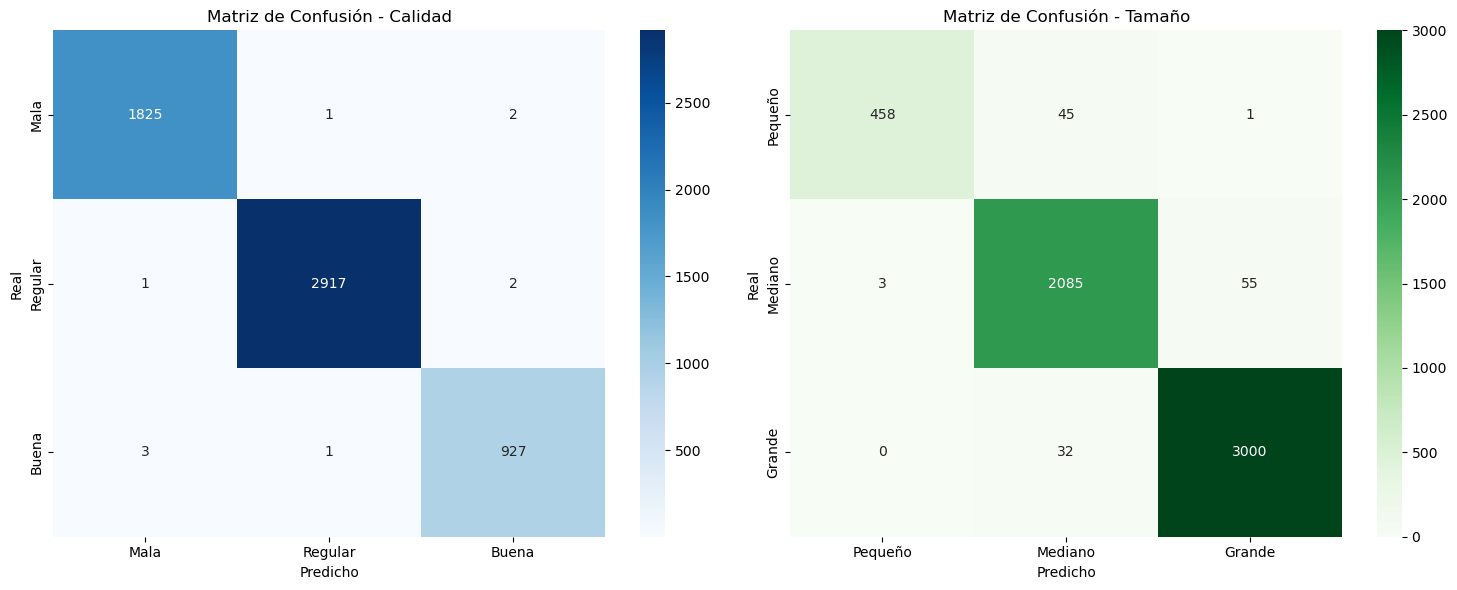

In [5]:
quality_names = ['Mala', 'Regular', 'Buena']
size_names = ['Pequeño', 'Mediano', 'Grande']

# y_test[:, 0] es calidad, y_test[:, 1] es tamaño
evaluate_multioutput_model(y_test[:, 0], y_pred_rf[:, 0],
                           y_test[:, 1], y_pred_rf[:, 1],
                           quality_classes=quality_names,
                           size_classes=size_names)

### 4. Ajuste de Hiperparámetros (Hyperparameter Tuning)

Aplicamos `GridSearchCV` para evitar el overfitting y encontrar la mejor combinación de parámetros. 

**Nota:** al usar `MultiOutputClassifier` y `Pipeline`, debemos acceder a los parámetros del modelo base especificando la ruta completa en el diccionario de parámetros: `classifier__estimator__<parametro>`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# RandomizedSearch prueba solo 20 combinaciones aleatorias en lugar de 90
param_dist = {
    'classifier__estimator__n_estimators': randint(50, 200),
    'classifier__estimator__max_depth': [None, 10, 20, 30],
    'classifier__estimator__min_samples_split': [2, 5, 10]
}

grid_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=20,        # ← solo 20 combinaciones aleatorias (era 90)
    cv=3,             # ← 3 pliegues en lugar de 5
    n_jobs=4,         # ← máximo 4 núcleos en lugar de todos los 20
    verbose=1,
    random_state=42
)

grid_search.fit(X_train, y_train)
print(f'Mejores parámetros encontrados: {grid_search.best_params_}')
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


### 5. Evaluación del Mejor Modelo Encontrado

In [ ]:
y_pred_best = best_rf_model.predict(X_test)

evaluate_multioutput_model(y_test[:, 0], y_pred_best[:, 0],
                           y_test[:, 1], y_pred_best[:, 1],
                           quality_classes=quality_names,
                           size_classes=size_names)

### 6. Guardar el Modelo Entrenado

Guardamos el mejor modelo utilizando `joblib` para poder consumirlo posteriormente en la interfaz de Streamlit (`app.py`).

In [ ]:
model_path = '../models/best_rf_multioutput.pkl'
os.makedirs('../models', exist_ok=True)

joblib.dump(best_rf_model, model_path)
print(f'Modelo guardado exitosamente en: {model_path}')